In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,recall_score,precision_score,f1_score,r2_score

from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import plot_tree

In [2]:
data = pd.read_csv("ecommerce.csv")
data.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [3]:
data["Revenue"] = data["Revenue"].map({
    True:1,
    False:0
})

data["Weekend"] = data["Weekend"].map({
    True:1,
    False:0
})

# data = data.drop(columns=["Month","VisitorType"])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [4]:
data.select_dtypes("object").columns

Index(['Month', 'VisitorType'], dtype='object')

In [5]:
# encoder = OneHotEncoder(
#     sparse_output=False,
#     handle_unknown='ignore',
#     drop="first"
# )

# one_hot_cols = ["Month","VisitorType"]

# encoded = encoder.fit_transform(data[one_hot_cols])

# encoded_df = pd.DataFrame(
#     encoded,
#     columns=encoder.get_feature_names_out(one_hot_cols),
#     index=data.index

# )

# data = pd.concat([data.drop(columns=one_hot_cols),encoded_df])
# data.head()

In [6]:
one_hot_encoder = OneHotEncoder(
    sparse_output=False,
    drop="first",
    handle_unknown='ignore'
)

one_hot_cols = ["Month","VisitorType"]

encoded = one_hot_encoder.fit_transform(data[one_hot_cols])
one_hot_encoder.get_feature_names_out(one_hot_cols)

array(['Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar',
       'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep',
       'VisitorType_Other', 'VisitorType_Returning_Visitor'], dtype=object)

In [7]:
encoded_df = pd.DataFrame(
    encoded,
    columns=one_hot_encoder.get_feature_names_out(one_hot_cols),
    index=data.index
)

data = pd.concat([data.drop(columns=one_hot_cols),encoded_df],axis=1)

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  int64  
 11  Browser                        12330 non-null  int64  
 12  Region                         12330 non-null 

In [8]:
data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [9]:
data.columns = [i.lower() for i in data.columns]

data.corr()

,administrative,administrative_duration,informational,informational_duration,productrelated,productrelated_duration,bouncerates,exitrates,pagevalues,specialday,...,month_feb,month_jul,month_june,month_mar,month_may,month_nov,month_oct,month_sep,visitortype_other,visitortype_returning_visitor
administrative,1.000000,0.601583,0.376850,0.255848,0.431119,0.373939,-0.223563,-0.316483,0.098990,-0.094778,...,-0.065649,0.006221,-0.001902,-0.055036,-0.064587,0.051574,0.091266,0.059607,-0.021184,-0.022884
administrative_duration,0.601583,1.000000,0.302710,0.238031,0.289087,0.355422,-0.144170,-0.205798,0.067608,-0.073304,...,-0.044524,-0.002096,-0.018974,-0.023198,-0.039318,0.032432,0.055101,0.031313,-0.008542,-0.022525
informational,0.376850,0.302710,1.000000,0.618955,0.374164,0.387505,-0.116114,-0.163666,0.048632,-0.048219,...,-0.040372,0.001896,0.007176,-0.027957,-0.038422,0.063754,-0.002619,0.009692,-0.021457,0.057399
informational_duration,0.255848,0.238031,0.618955,1.000000,0.280046,0.347364,-0.074067,-0.105276,0.030861,-0.030577,...,-0.028060,0.014958,-0.015407,-0.011545,-0.031811,0.036899,0.006434,0.001744,-0.013489,0.045501
productrelated,0.431119,0.289087,0.374164,0.280046,1.000000,0.860927,-0.204578,-0.292526,0.056282,-0.023958,...,-0.056863,0.020034,0.015072,-0.114672,-0.072220,0.182339,0.008907,0.005997,-0.036083,0.128738
productrelated_duration,0.373939,0.355422,0.387505,0.347364,0.860927,1.000000,-0.184541,-0.251984,0.052823,-0.036380,...,-0.046550,0.002276,0.001506,-0.085491,-0.068133,0.166951,-0.008773,0.005950,-0.027183,0.120489
bouncerates,-0.223563,-0.144170,-0.116114,-0.074067,-0.204578,-0.184541,1.000000,0.913004,-0.119386,0.072702,...,0.063030,0.009766,0.041178,-0.004090,0.059062,-0.034281,-0.046044,-0.040081,0.028112,0.129908
exitrates,-0.316483,-0.205798,-0.163666,-0.105276,-0.292526,-0.251984,0.913004,1.000000,-0.174498,0.102242,...,0.078709,0.008852,0.048276,0.013439,0.072815,-0.056810,-0.062465,-0.050956,0.034763,0.171987
pagevalues,0.098990,0.067608,0.048632,0.030861,0.056282,0.052823,-0.119386,-0.174498,1.000000,-0.063541,...,-0.033137,-0.018317,-0.020804,-0.044451,-0.015099,0.037856,0.032046,0.017439,0.055204,-0.115825
specialday,-0.094778,-0.073304,-0.048219,-0.030577,-0.023958,-0.036380,0.072702,0.102242,-0.063541,1.000000,...,0.106596,-0.058845,-0.047759,-0.132095,0.464809,-0.175039,-0.066666,-0.059966,-0.025730,0.087123


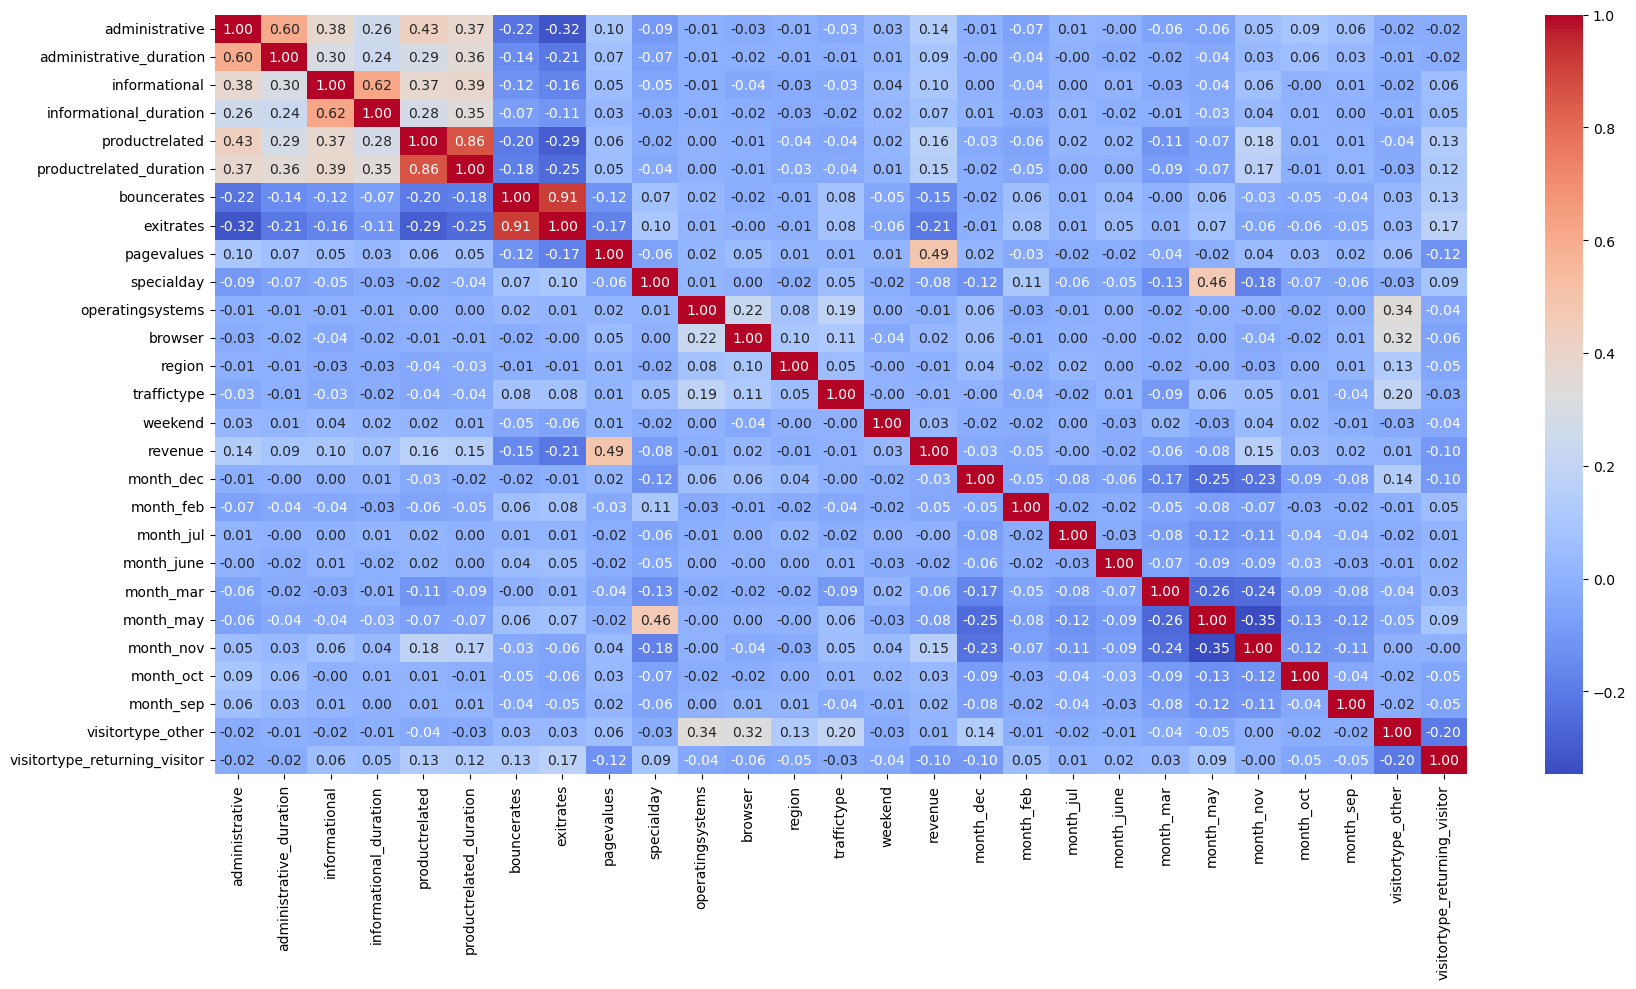

In [10]:
plt.figure(figsize=(18,10))
sns.heatmap(
    data.corr(),
    annot=True,
    fmt = ".2f",
    cmap="coolwarm"
)

plt.tight_layout()



<Axes: xlabel='revenue', ylabel='productrelated_duration'>

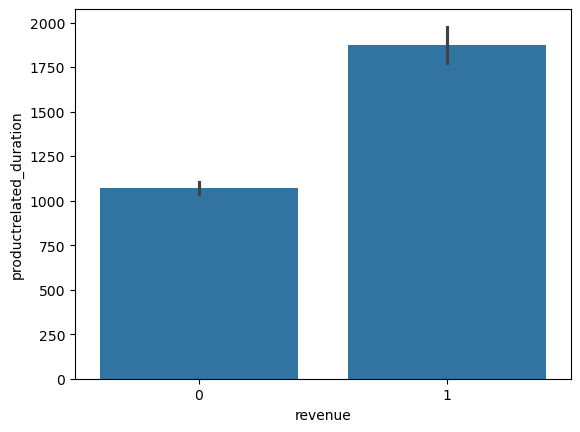

In [11]:

sns.barplot(
    data,
    x="revenue",
    y="productrelated_duration"
)

In [12]:
X=data.drop(columns=["revenue","weekend","region","operatingsystems","traffictype","browser"])
Y = data["revenue"]

scaler = StandardScaler()
X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,
    test_size=0.2,
    random_state=42
)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train,Y_train)

Y_pred = model.predict(X_test)

print(confusion_matrix(Y_test,Y_pred))

print(classification_report(Y_test,Y_pred))

[[1878  177]
 [ 186  225]]
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      2055
           1       0.56      0.55      0.55       411

    accuracy                           0.85      2466
   macro avg       0.73      0.73      0.73      2466
weighted avg       0.85      0.85      0.85      2466



In [14]:
max_depths = [i for i in range(2,5)]
best_depth = 0
best_f1 = 0
for i in max_depths:
    model = DecisionTreeClassifier(
        max_depth=i,
        min_samples_split=380
    )
    model.fit(X_train,Y_train)
    Y_pred = model.predict(X_test)

    f1 = f1_score(Y_test,Y_pred)
    if(f1>best_f1):
        best_depth = i
        best_f1=f1
print(i)
print(best_f1)

4
0.6770708283313326


In [15]:
full_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=600
)
full_tree.fit(X_train,Y_train)
Y_pred = full_tree.predict(X_test)

path = full_tree.cost_complexity_pruning_path(X_train,Y_train)

ccp_alphas = path.ccp_alphas
print(ccp_alphas.shape)

(12,)


In [16]:
trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha,
        max_depth=4,
        min_samples_split=380
    )
    model.fit(X_train,Y_train)
    Y_pred = model.predict(X_test)
    trees.append((model,alpha))

In [17]:
best_f1 = 0
best_alpha = 0

for model,alpha in trees:
    print(alpha)
    Y_pred = model.predict(X_test)
    f1 = f1_score(Y_test,Y_pred)
    if(f1>best_f1):
        best_f1 = f1
        best_alpha=alpha
print(best_f1,best_alpha)

0.0
0.0001817123819637008
0.00019909240402286518
0.0002527499972586958
0.0003566620912683338
0.0013433245883283512
0.001906013423500906
0.002327201787698116
0.00341064637828737
0.0036595099344895188
0.01014735484966943
0.09360907985524447
0.6770708283313326 0.0


In [18]:
best_model = DecisionTreeClassifier(
    ccp_alpha=best_alpha,
    random_state=42,
    max_depth=4,
    min_samples_split=600,
)
best_model.fit(X_train,Y_train)
Y_pred = best_model.predict(X_test)
print(classification_report(Y_test,Y_pred))
print(f1_score(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.94      0.93      0.93      2055
           1       0.67      0.69      0.68       411

    accuracy                           0.89      2466
   macro avg       0.80      0.81      0.81      2466
weighted avg       0.89      0.89      0.89      2466

0.6770708283313326


In [19]:
print(confusion_matrix(Y_test,Y_pred))

[[1915  140]
 [ 129  282]]


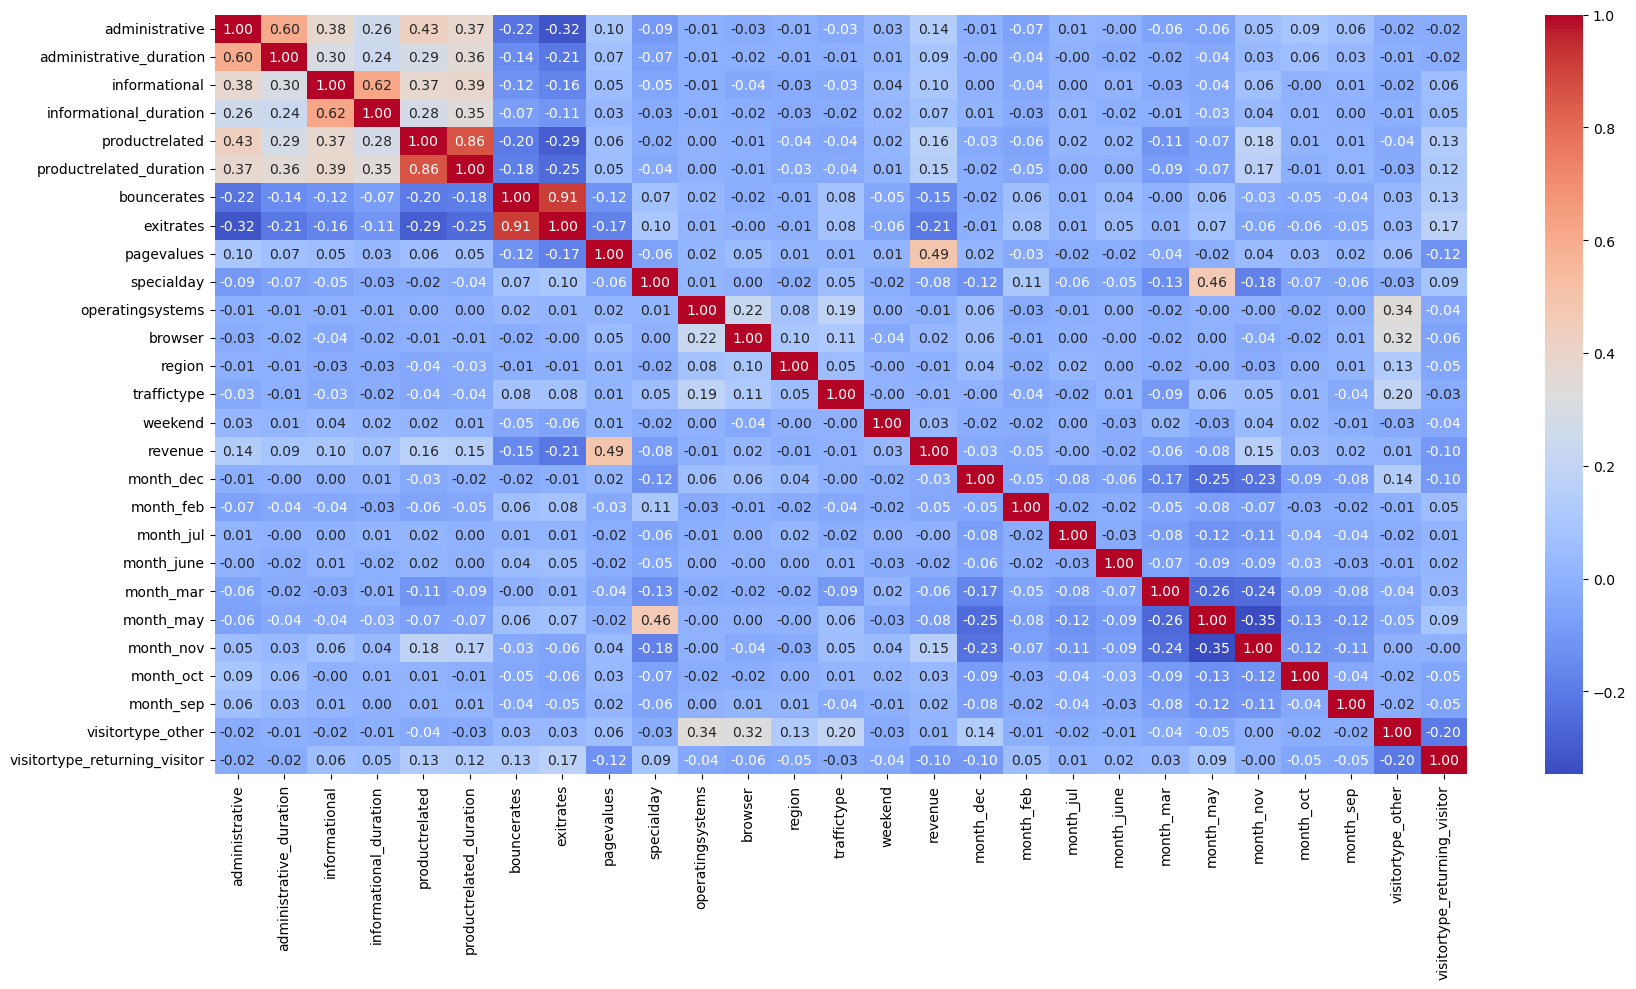

In [20]:

plt.figure(figsize=(18,10))
sns.heatmap(
    data.corr(),
    fmt = ".2f",
    annot=True,
    cmap ="coolwarm"
)

plt.tight_layout()

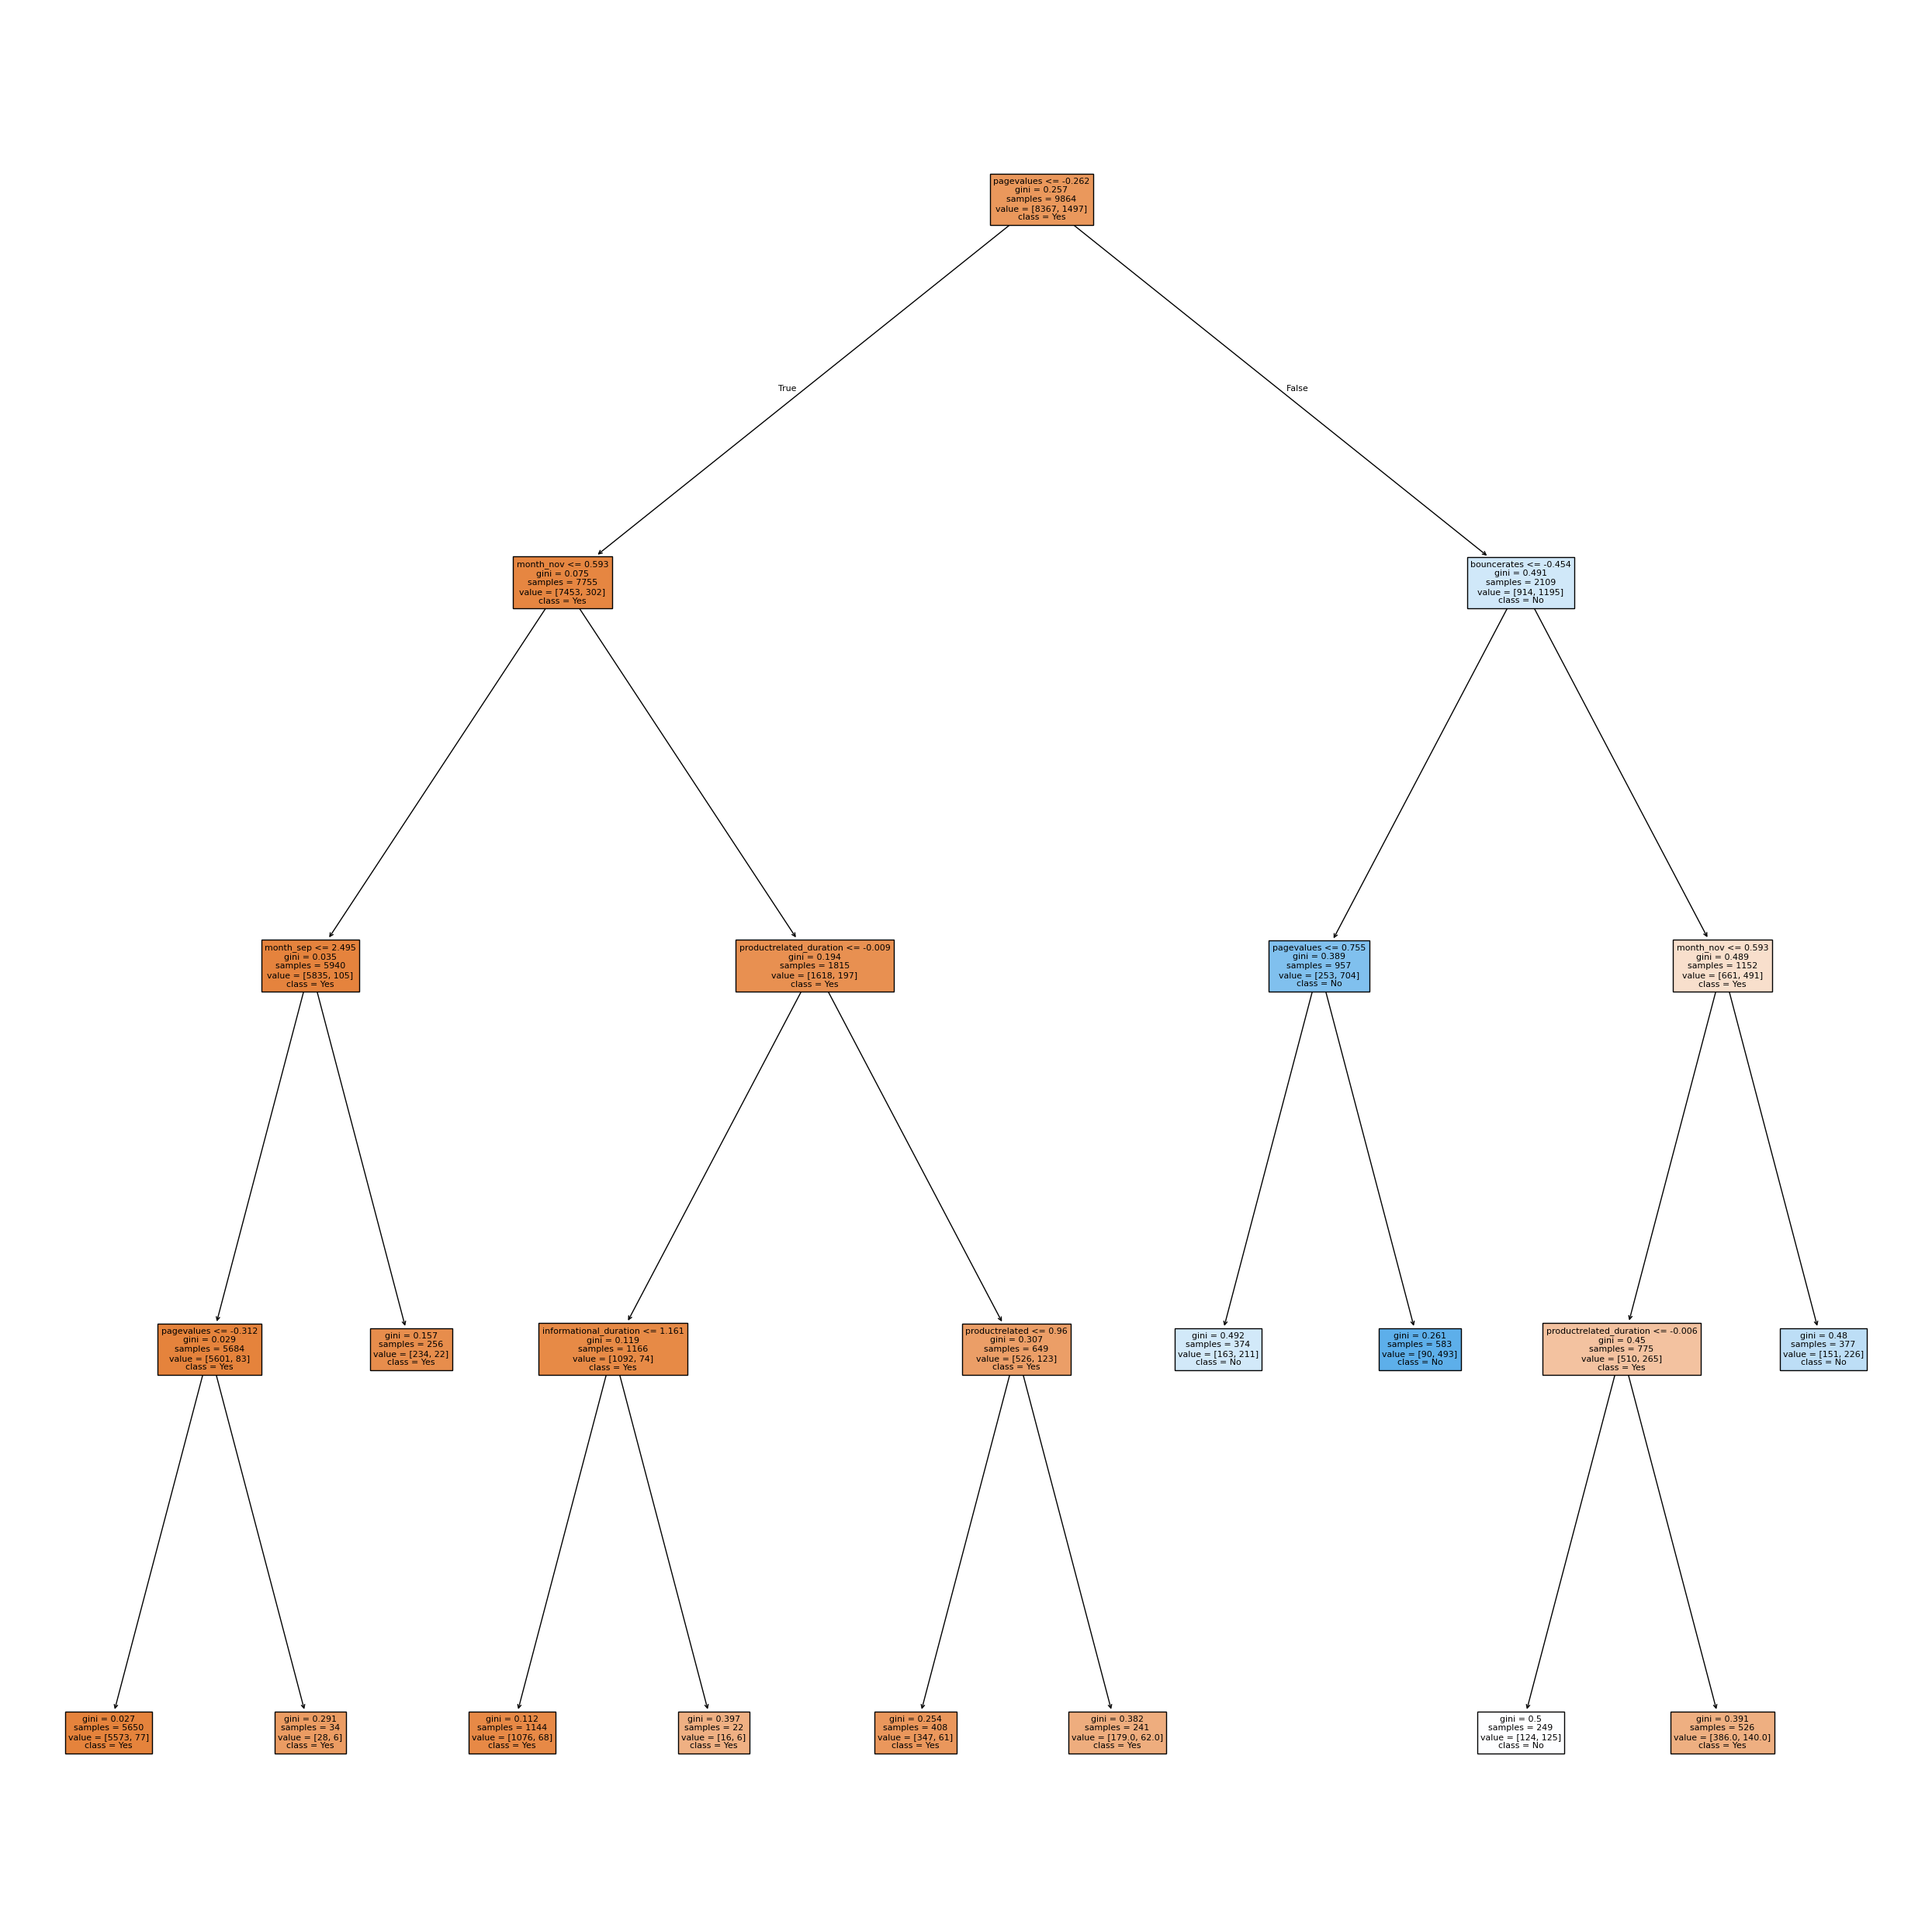

In [21]:
plt.figure(figsize=(25,25))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Yes","No"],
    filled=True
)
plt.tight_layout()

In [32]:
X = data.drop(columns=["operatingsystems","browser","region","traffictype","revenue","weekend"])
Y = data["revenue"]

scaler = StandardScaler()
X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,
    test_size=0.2,
    random_state=42
)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = DecisionTreeClassifier()
model.fit(X_train,Y_train)

Y_pred = model.predict(X_test)

print(confusion_matrix(Y_test,Y_pred))

print(classification_report(Y_test,Y_pred))

[[1878  177]
 [ 187  224]]
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      2055
           1       0.56      0.55      0.55       411

    accuracy                           0.85      2466
   macro avg       0.73      0.73      0.73      2466
weighted avg       0.85      0.85      0.85      2466

